# End-to-end TopoMetry analysis and report 

Single-cell genomics measures thousands of genes per cell, producing high-dimensional, noisy data with uneven sampling across cell states. Most analysis pipelines compress these measurements into a lower-dimensional representation and then build a graph of cell–cell similarities for downstream tasks such as clustering, trajectories, and visualization. Despite being key to the downstream results, there are little guarantees that most representations preserve the original geometry of the data, and there is no clear way for users to inspect these representations or visualizations to obtain additional insights.  

TopoMetry approaches this task by encoding the data’s latent geometry in a spectral scaffold that captures structure across scales. The scaffold's latent geometry is then represented by a refined graph which encodes cell-cell similarities. The refined graph can be used for enhanced clustering and visualization, imputation, pseudotime analysis and other downstream tasks. `topometry` also uses manifold metrics to estimate and visualize the distortions induced in single-cell representations and visualizations, allowing users to compare and investigate them before proceeding with downstream analyses.

In this tutorial you’ll learn how to run the fully automated TopoMetry workflow in a single line of code, generating a PDF report. 

`topometry` is fully compatible with `scanpy` and the `scverse` suite of tools for single-cell analyses in python.

In [1]:
# imports
import scanpy as sc
import topo as tp

# figure settings
sc.settings.set_figure_params(dpi=120, facecolor='white', fontsize=14)

# suppress scanpy warnings (optional, but makes notebook cleaner)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

We’ll use the PBMC 3k dataset from 10x Genomics—a small, widely used dataset composed of peripheral blood mononuclear cells. We'll use `scanpy` [standard workflow](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html#) for comparisons. 

Before analysis we perform minimal quality control to filter cells with very few detected genes and genes expressed in very few cells. 

In [2]:
# load data
adata = sc.datasets.pbmc3k()

# minimal QC
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

## Expected normalization

TopoMetry expects ***Z-score–normalized*** (standardized) expression values for a set of highly-variable genes (HVGs). Concretely: after normalization and log-transform, select HVGs, then scale each gene to mean 0 and unit variance (optionally clipping extreme values). 

The automated wrapper `tp.sc.preprocess(adata)` performs exactly these preprocessing steps and prepares adata.X for TopoMetry’s base graph construction.

In [3]:
adata = tp.sc.preprocess(adata)

The `tp.sc.preprocess(adata)` wrapper is equivalent to the legacy `scanpy` preprocessing:

```
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=3)
```

and automatically handles `adata.layers` and `adata.raw`. 

## Current standard baseline

Most single-cell workflows use PCA to obtain ~30–50 principal components, build a kNN graph on those PCs, and then compute a 2D UMAP for visualisation. This is fast and familiar, but it assumes variance-dominant, approximately linear structure and a uniform manifold metric—assumptions often violated in practice.

To ground our intuition, we’ll also show UMAP computed (a) on PCA space and (b) directly on the scaled HVG space. This provides a baseline to compare with TopoMetry’s geometry-aware layouts later.

In [4]:
# run PCA
sc.pp.pca(adata, layer="scaled", svd_solver="arpack")

# PCA + UMAP baseline
sc.pp.neighbors(adata, n_pcs=40, use_rep='X_pca', metric='cosine', key_added='pca')
sc.tl.leiden(adata, resolution=0.5, neighbors_key='pca', key_added='pca_leiden')
sc.tl.umap(adata, neighbors_key='pca')
adata.obsm['X_PCA_UMAP'] = adata.obsm['X_umap'].copy()
del adata.obsm['X_umap'] #remove duplicate key

# UMAP on adata.X baseline
sc.pp.neighbors(adata, n_pcs=0, use_rep='X', metric='cosine', key_added='X')
sc.tl.leiden(adata, resolution=0.5, neighbors_key='X', key_added='X_leiden')
sc.tl.umap(adata, neighbors_key='X')
adata.obsm['X_UMAP_on_adataX_'] = adata.obsm['X_umap'].copy()
del adata.obsm['X_umap'] #remove duplicate key


2025-09-18 15:13:28.021632: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


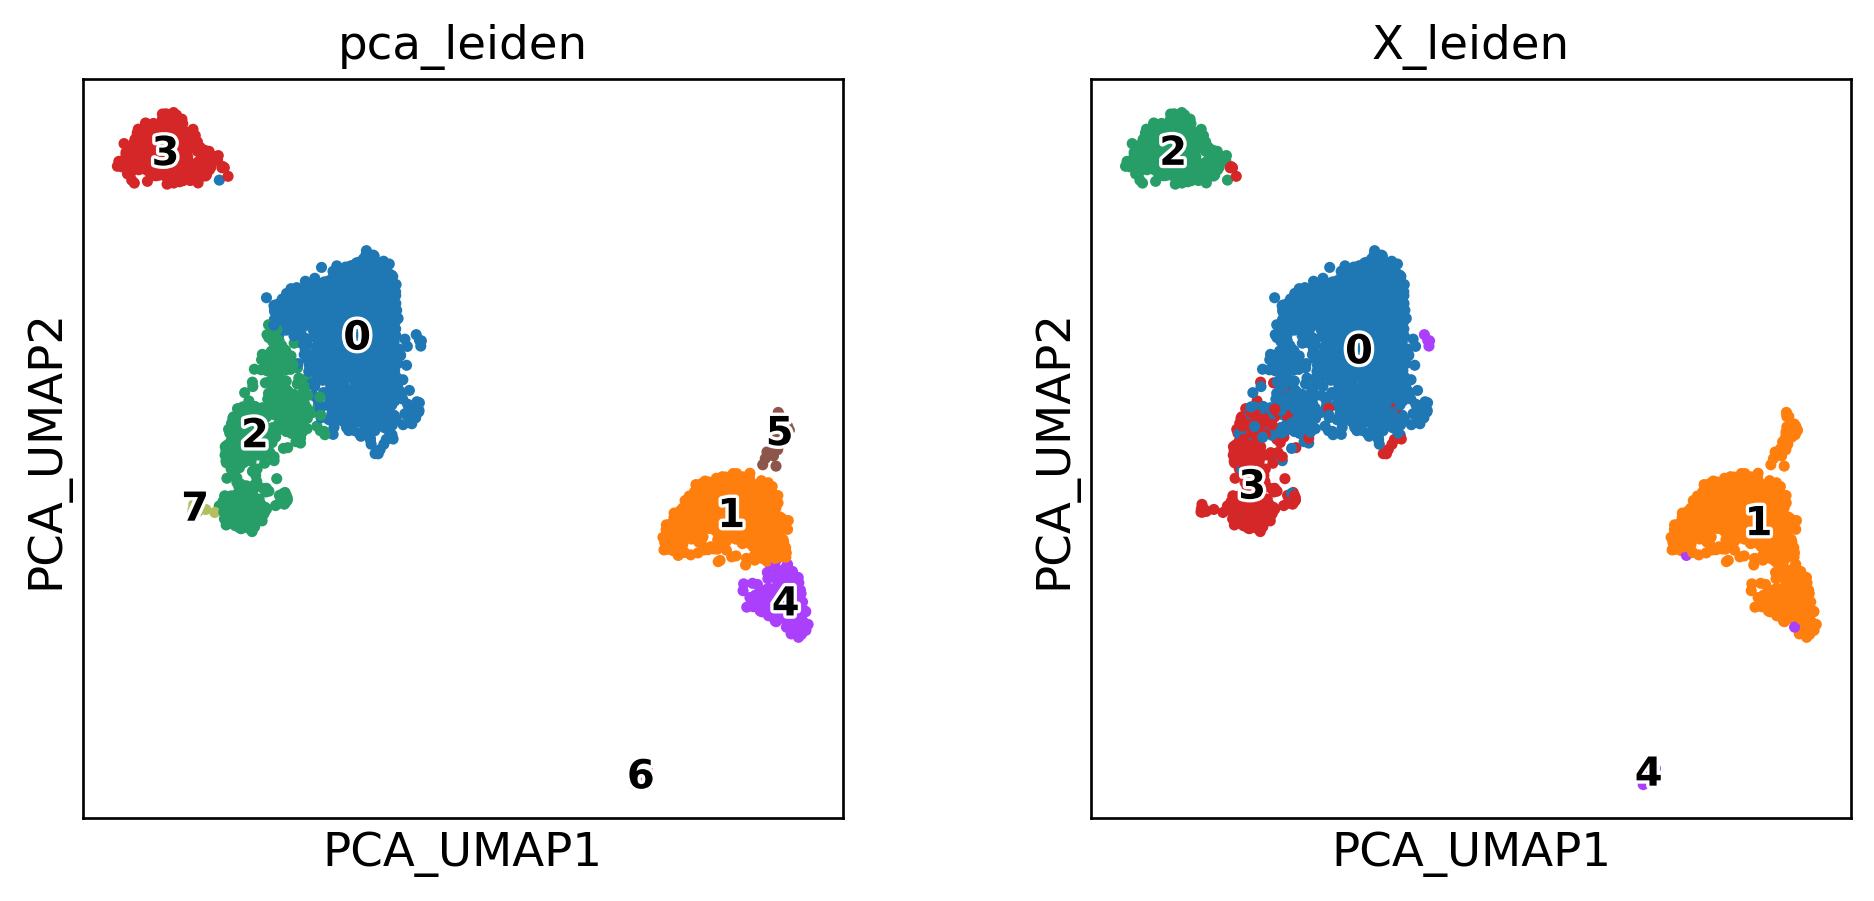

In [5]:
sc.pl.embedding(adata, basis='PCA_UMAP', color=['pca_leiden','X_leiden'], legend_loc='on data', legend_fontsize=12, legend_fontoutline=2)

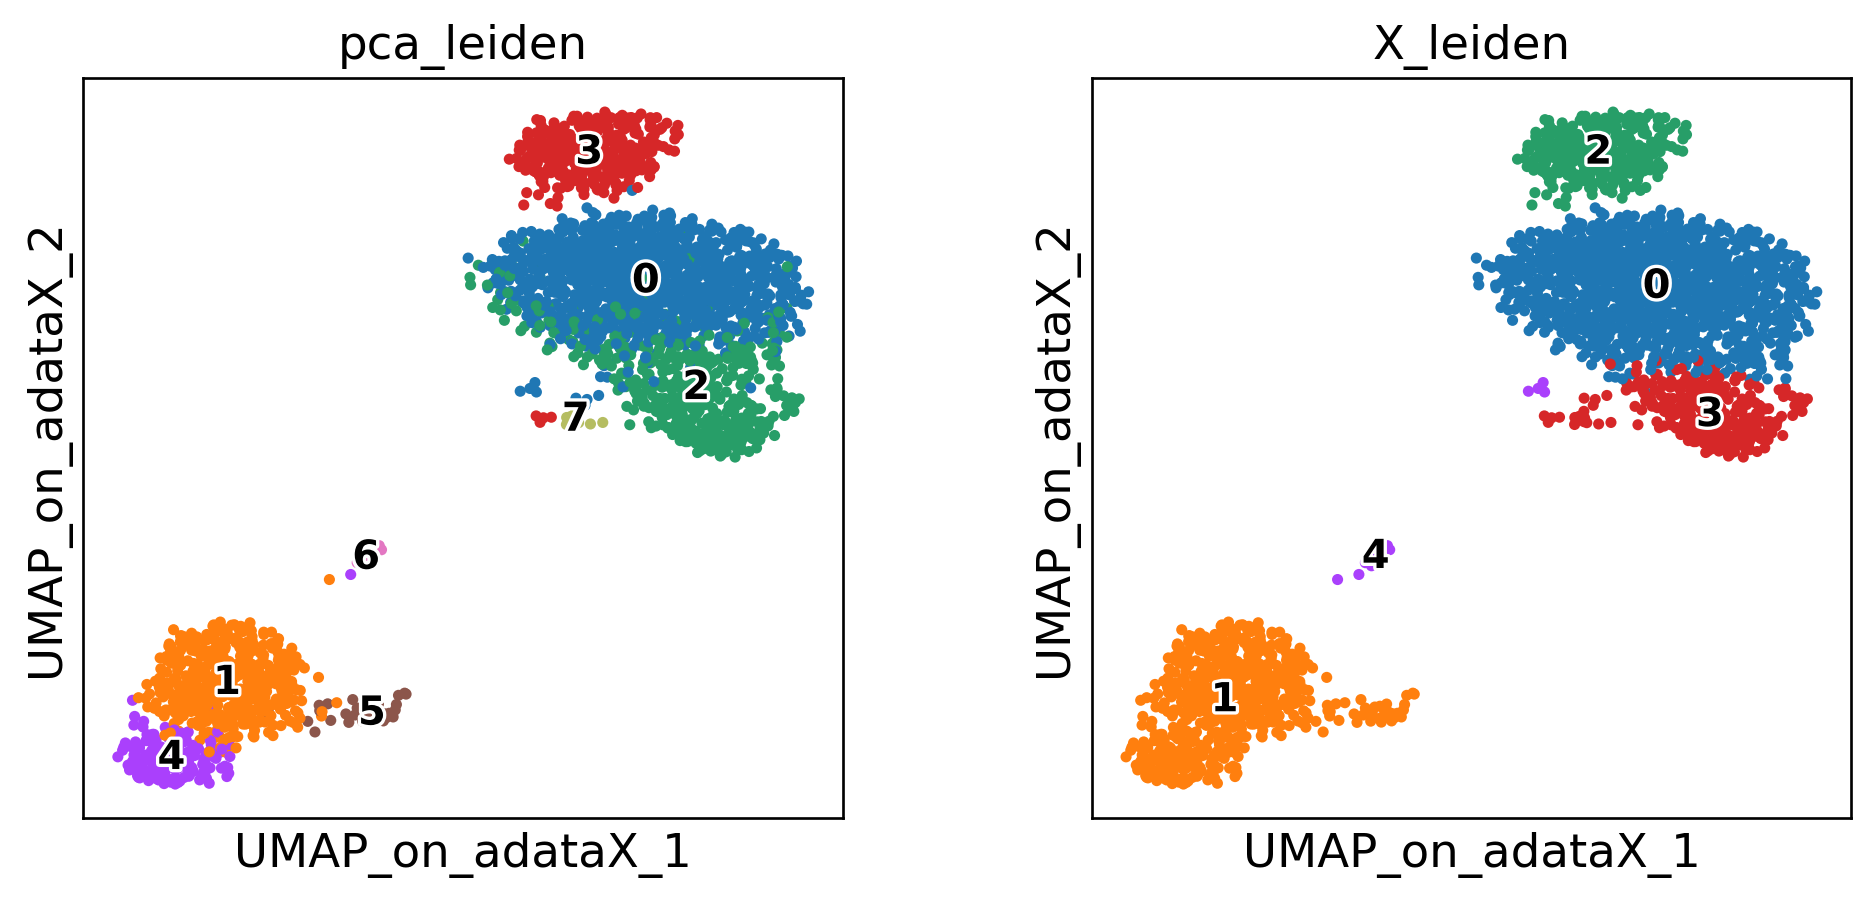

In [6]:
sc.pl.embedding(adata, basis='UMAP_on_adataX_', color=['pca_leiden','X_leiden'], legend_loc='on data', legend_fontsize=12, legend_fontoutline=2)

These embeddings are well-known. The standard "PCA-UMAP" workflow provides better global separation of main clusters, but misses local information captured by the "pure" UMAP.

Now, let's perform the TopoMetry analysis:

## The TopoMetry pipeline

TopoMetry: 
* 1) builds a base neighbourhood graph from the scaled HVG matrix; 
* 2) estimates intrinsic dimensionality to size each scaffold;
* 3) computes two spectral scaffolds (fixed diffusion time and multiscale); 
* 4) rebuilds refined graphs on these scaffolds;
* 5) produces 2D layouts (MAP/PaCMAP); 
* 6) computes geometry-preservation metrics that quantify how well neighbourhoods and diffusion structure are maintained.


You can execute the full analysis with default parameters with a single call to `tp.sc.run_and_report(adata)`, which returns the fitted TopOGraph object and writes a PDF summarizing results. 

In [7]:
# --- One-command analysis & PDF report ---
tg, pdf_path = tp.sc.run_and_report(adata,
    filename="my_topometry_report.pdf",
    n_jobs=-1,    # use all available CPU cores - topometry is highly parallelizable
    verbosity=0
)
print(f"PDF report saved to: {pdf_path}")

PDF report saved to: ./my_topometry_report.pdf


That's it! Now you can read the report.

##  Reading the report

**1) Geometry-preservation metrics**

A central part of the report is the geometry-preservation scoring, which quantify how well the scaffolds and layouts respect the original data geometry. TopoMetry uses four complementary metrics, each probing different scales of structure:

* **PF1 (Top-k Row-Neighborhood F1):** compares the sets of strongest neighbors per cell in two operators. Insensitive to weights, it captures whether the *identity of neighbors* is preserved.

* **Row-wise Jensen–Shannon similarity (PJS):** compares transition **weights** per row by measuring similarity of probability distributions. Sensitive to the *strength* of connections, not just their presence.

* **Spectral Procrustes (SP):** aligns diffusion eigencoordinates between operators and reports $R^2$. Sensitive to **meso- and global-scale geometry**, testing whether the manifold shape is preserved.

* **Commute-time Trace Gap (CT):** compares traces of Laplacian pseudoinverses (Kirchhoff index proxies). Summarises **global random-walk connectivity**, i.e. whether cells remain similarly accessible in the graph.

**How to read it:**

* High **PF1** + **PJS** → local neighborhood fidelity (sets + weights).
* High **SP** → preservation of manifold-level geometry.
* High **CT** → similar global connectivity.
  Consistency across all four metrics indicates robust preservation across **local, meso, and global scales**.


**2) Eigenspectrum (scree) & spectral scaffold size**

The eigenspectrum shows how much information each diffusion component carries. A steep drop followed by a plateau would suggest a low intrinsic dimensionality; however, single-cell data usually exhibits a gentle decay, indicating that many components are needed to capture its heterogeneity. This is why TopoMetry works with hundreds of components instead of the ~30 PCs used in standard workflows.
The report lists the automatically chosen scaffold sizes for both multiscale diffusion maps (msDM) and fixed-time diffusion maps (DM), estimated from intrinsic-dimensionality measures (MLE and FSA). These scaffold sizes are the number of coordinates retained for downstream graph building and projections.

**3) Intrinsic dimensionality (global & local)**

TopoMetry estimates intrinsic dimensionality at both global and local levels:

* Global (MLE / FSA): summarises the dataset’s overall complexity, i.e. the effective degrees of freedom needed to describe all cells. Global MLE is based on the median of local estimates, while FSA uses quantiles. Both are proxies, and they typically differ by a small margin.

* Local IDs: per-cell estimates that capture how “complex” a neighbourhood is. Regions with high local ID values often correspond to transitional or heterogeneous populations (e.g. proliferating cells, mixed states, branch points in trajectories). Regions with low IDs usually correspond to homogeneous, compact populations (e.g. naive T cells). Visualising the distribution of local IDs in the report helps identify which populations are geometrically complex.

**4) Layouts (msTopoMAP vs TopoMAP)**

The report presents 2D embeddings generated with MAP optimisation on two scaffolds:

msTopoMAP (multiscale): captures relationships across multiple diffusion timescales. This usually balances local detail with broader organisation, making it the preferred layout in most analyses.

TopoMAP (fixed-time DM): focuses on a single diffusion timescale (diff_t). This can sharpen local structures or highlight specific transitional paths.

Comparing the two is informative: if both show similar organisation, the geometry is stable; if they differ, the dataset may contain structures visible only at certain scales.


**5) Clustering & annotations**

Unless otherwise specified, `run_and_report` clusters the refined graph with the Leiden algorithm at different resolutions. These appear in the repport as coloured overlays on msTopoMAP and TopoMAP layouts.
The strength of TopoMetry lies in preserving the latent geometry; cluster boundaries are one way to summarise that structure. Use markers, differential expression, or biological knowledge to explore and refine clusters.


**6) Imputation**

TopoMetry can produce smoothed gene-expression estimates by diffusing signals across the scaffold graph. The imputation panel shows such denoising for one or more marker genes. This helps visualise marker gradients more clearly and reduce dropout artefacts.
Important caveat: imputed values are not raw counts—they are reconstructions guided by the manifold. Use them for visualisation (heatmaps, layouts) but avoid using them in quantitative downstream analyses such as differential expression.

## Next steps

After completion, your `AnnData` will be populated with:

* **Spectral Scaffold coordinates:** `adata.obsm['X_spectral_scaffold']`, `adata.obsm['X_multiscale_scaffold']`.
    * Construct your own neighborhood graphs on these scaffolds using `sc.pp.neighbors(adata, use_rep='X_spectral_scaffold')` to generate custom UMAPs, clusters, etc.
    * For RNA velocity analyses, use `scv.pp.moments(adata, use_rep='X_msDM with bw_adaptive', n_neighbors=10)` [RNA velocity tutorial]()

* **2D layouts for visualization:** e.g., `adata.obsm['X_msTopoMAP']`, `adata.obsm['X_TopoMAP']`.
    * Visualize gene expression and metadata in `adata.obs` using `sc.pl.embedding(adata, basis='TopoMAP',...)`

* **Clustering keys:** e.g., `adata.obs['topo_clusters']` at requested resolutions.

* **Metrics & timings:** `adata.uns['topometry']` (includes geometry-preservation scores, scaffold sizes, solver timings, and settings for full reproducibility).

* **Imputated data:** imputed/smoothed signals stored in `adata.layers['topo_imputation']`.

In [8]:
adata

AnnData object with n_obs × n_vars = 2700 × 3000
    obs: 'n_genes', 'pca_leiden', 'X_leiden', 'topo_clusters_res0.2', 'topo_clusters_res0.8', 'topo_clusters_res1.2', 'topo_clusters', 'topo_clusters_ms_res0.2', 'topo_clusters_ms_res0.8', 'topo_clusters_ms_res1.2', 'topo_clusters_ms', 'id_fsa_k10', 'id_fsa_k90', 'id_mle_k10', 'id_mle_k90', 'spectral_EAS', 'spectral_RayScore', 'spectral_LAC', 'spectral_axis', 'spectral_axis_sign', 'spectral_radius', 'metric_deformation__X_PCA_UMAP', 'metric_deformation__X_UMAP_on_adataX_', 'metric_deformation__X_msTopoMAP', 'metric_deformation__X_TopoMAP', 'metric_deformation__X_msTopoPaCMAP', 'metric_deformation__X_TopoPaCMAP', 'topo_clusters_highestres', 'metric_contract_expand_TopoMAP', 'metric_anisotropy_TopoMAP', 'metric_logdetG_TopoMAP', 'metric_contract_expand_msTopoMAP', 'metric_anisotropy_msTopoMAP', 'metric_logdetG_msTopoMAP', 'metric_contract_expand_TopoPaCMAP', 'metric_anisotropy_TopoPaCMAP', 'metric_logdetG_TopoPaCMAP', 'metric_contract_expa

You can use these data to integrate TopoMetry outputs into your usual Scanpy workflow. For example, you can colour layouts by markers, compare clustering results, and export figures:

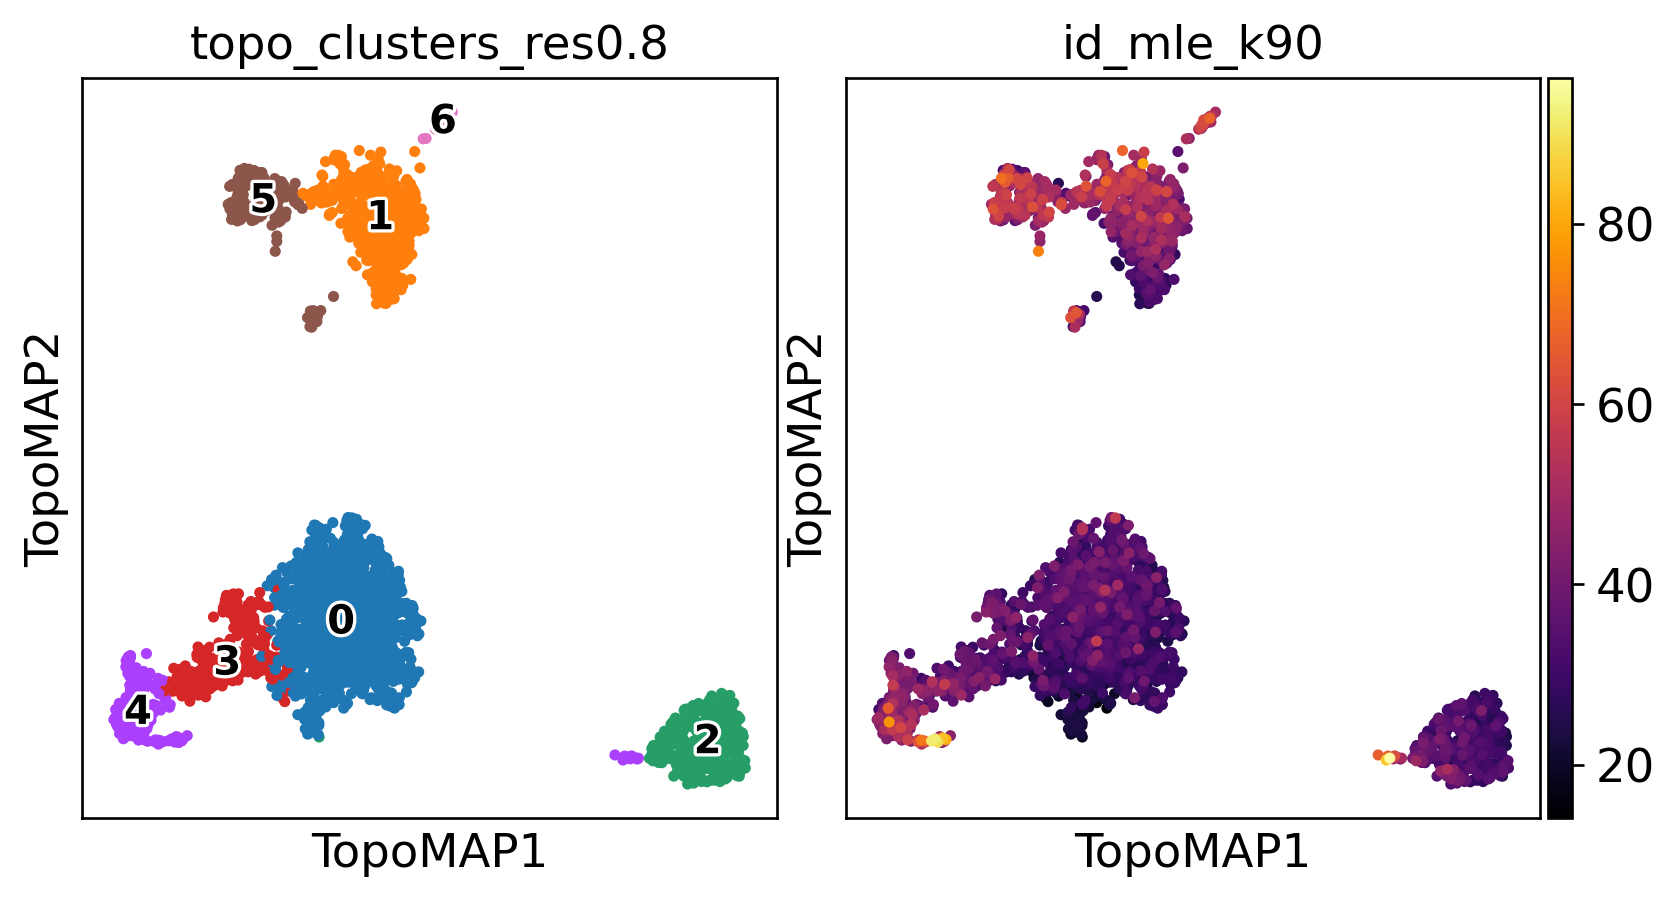

In [9]:
sc.pl.embedding(adata, basis='TopoMAP', color=['topo_clusters_res0.8','id_mle_k90'],
                 legend_loc='on data', legend_fontsize=12, legend_fontoutline=2, wspace=0, cmap='inferno')

You can also obtain some insight on the imputation process. Considering some classic PBMC marker genes:
* NKG7 - NK cells
* MS4A1 - B cells
* LYZ - macrophages
* FCER1A - dendritic cells


Let's visualize their normalized expression (stored in `adata.layers['scaled]`):

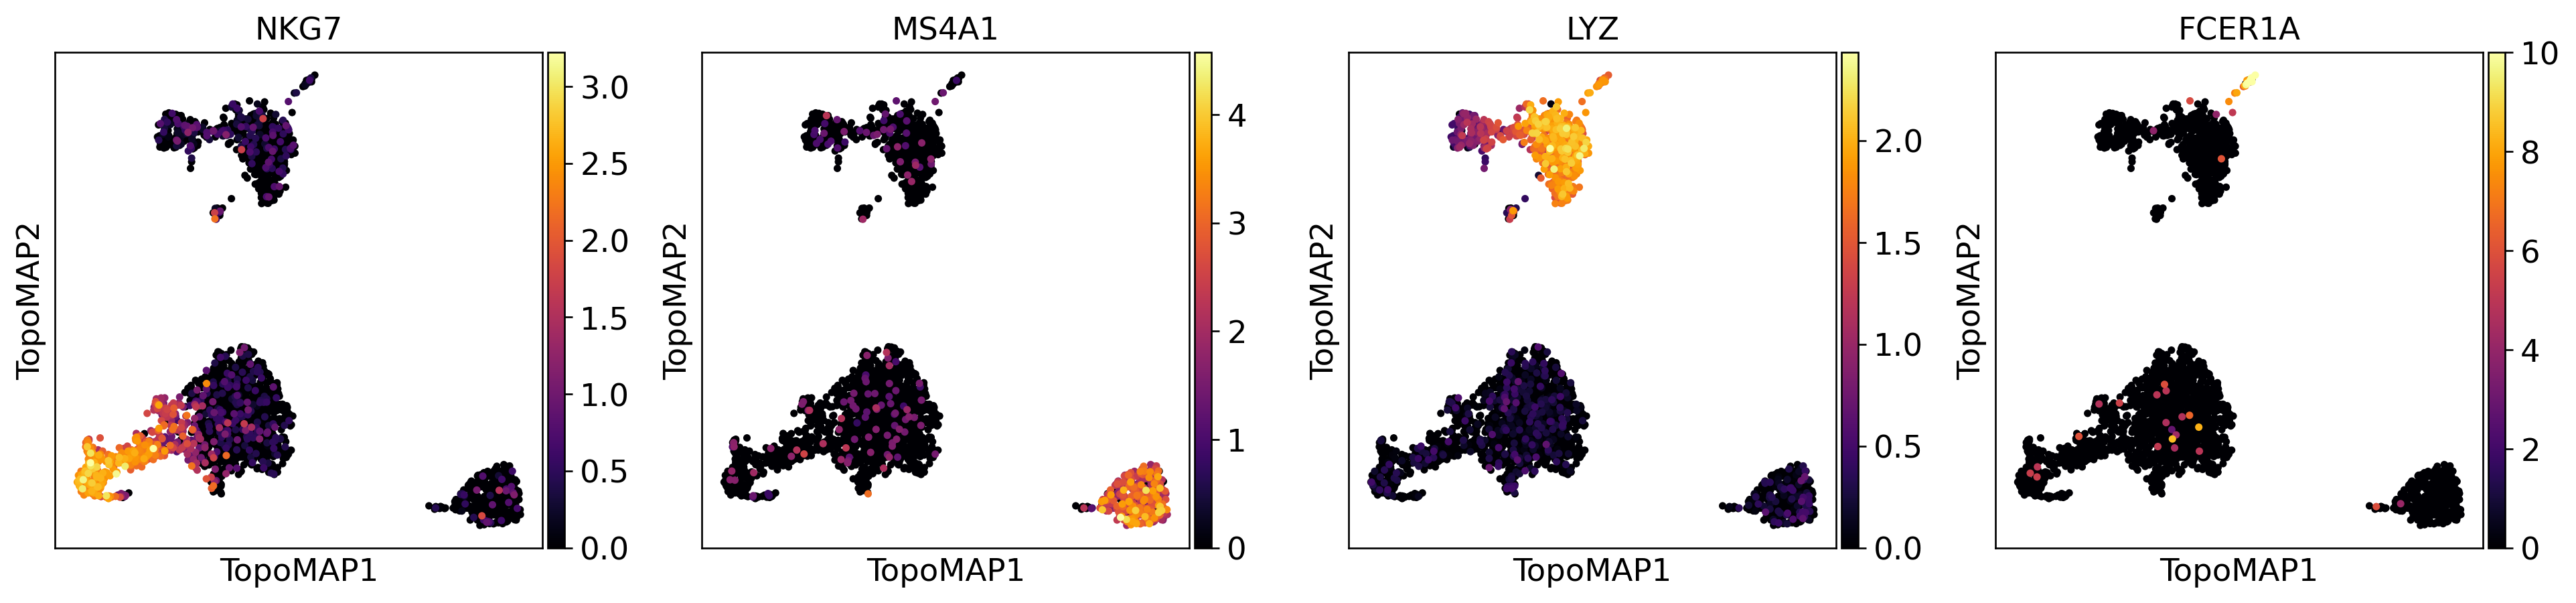

In [10]:
sc.pl.embedding(adata, basis='TopoMAP', color=['NKG7','MS4A1','LYZ','FCER1A'], cmap='inferno', layer='scaled', vmin=0)

Expression is higher in the cell population the gene marks, but there's still a lot of cells from other clusters with some expression. This can be attributed to technical artifacts in data generation such as doublets and ambient mRNA. 

Let's now see how their imputed values (stored at `adata.layers['topo_imputation]`) look like:

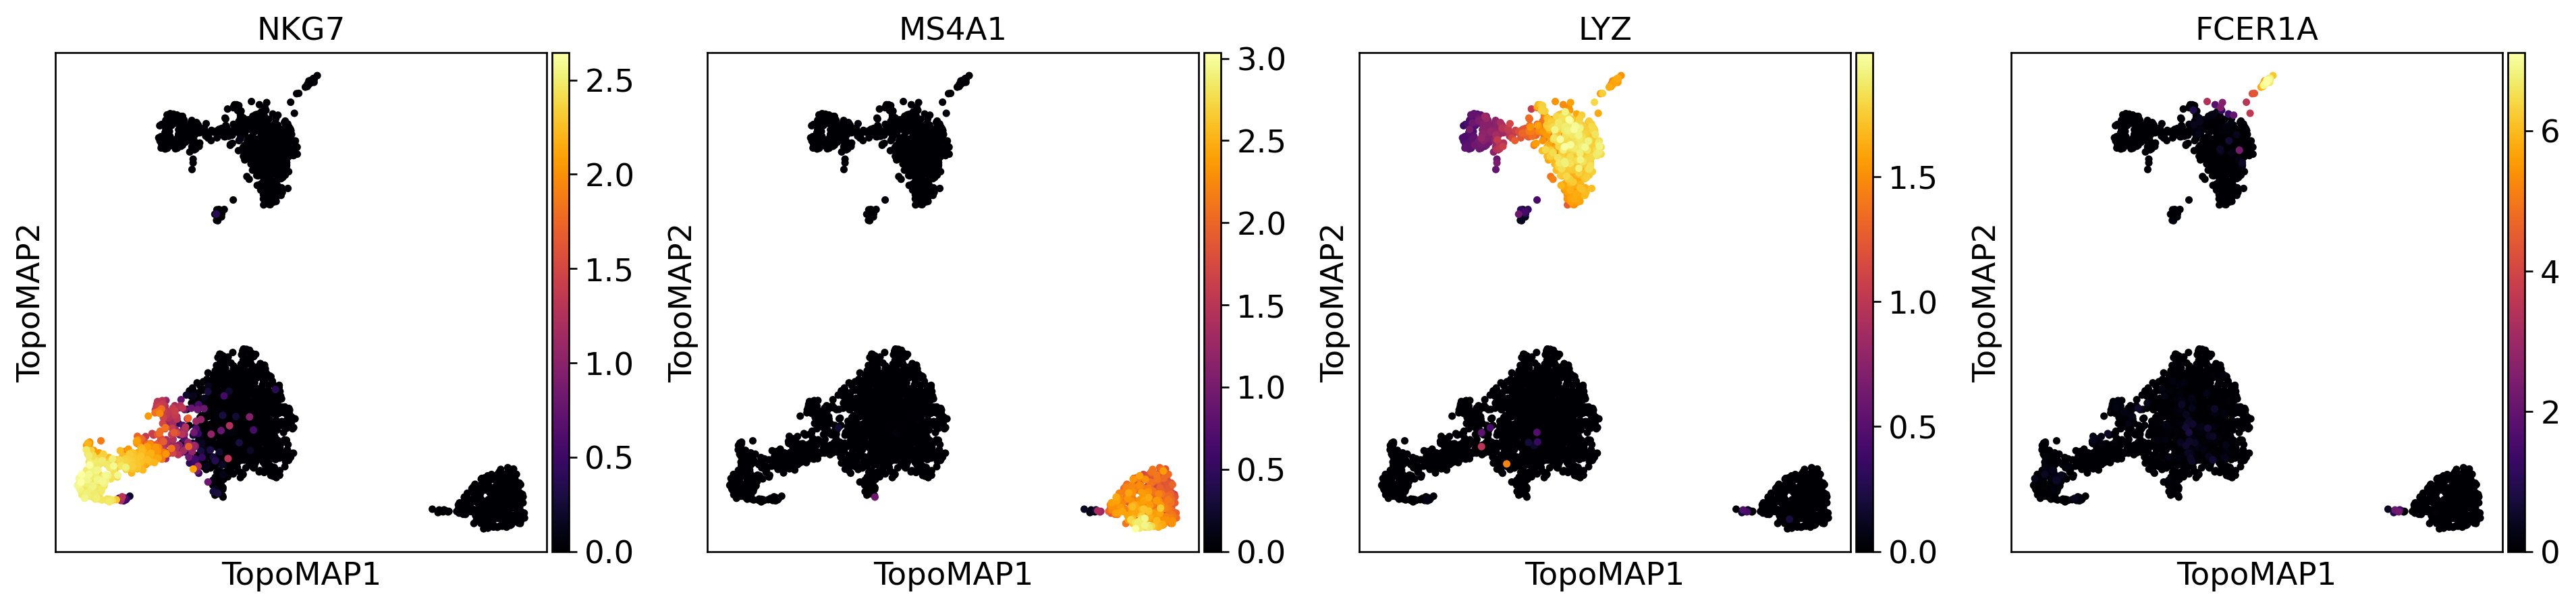

In [11]:
sc.pl.embedding(adata, basis='TopoMAP', color=['NKG7','MS4A1','LYZ','FCER1A'], cmap='inferno', layer='topo_imputation', vmin=0)

As you can see, the expression of marker genes is now almost entirely restricted to the cell population each gene is supposed to mark. The data was effectively denoised without introducing false-positive artifacts.

**What's next?**

1) Learn how to run and tune the analysis step-by-step
2) Explore the TopOGraph object
3) Check out additional examples of scRNAseq data analysis with comments on interpreting results